# Data Viewing - Perpetual Futures
Quick exploration of one exchange per coin to see data shape, trends, and summary statistics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-darkgrid')

# One different exchange per coin
files = {
    'BTC':  ('okx',         'data/BTC/okx_BTC_2019-12-16_2026-02-28.parquet'),
    'ETH':  ('binance',     'data/ETH/binance_ETH_2020-01-01_2026-03-01.parquet'),
    'SOL':  ('hyperliquid', 'data/SOL/hyperliquid_SOL_2023-05-12_2026-03-01.parquet'),
    'XRP':  ('gateio',      'data/XRP/gateio_XRP_2023-01-01_2026-02-28.parquet'),
    'DOGE': ('deribit',     'data/DOGE/deribit_DOGE_2020-01-01_2026-03-01.parquet'),
    'BNB':  ('okx',         'data/BNB/okx_BNB_2022-12-23_2026-02-28.parquet'),
    'AVAX': ('binance',     'data/AVAX/binance_AVAX_2020-01-01_2026-03-01.parquet'),
}

dfs = {}
for coin, (exchange, path) in files.items():
    df = pd.read_parquet(path, engine='fastparquet')
    # Strip exchange suffix from all columns
    df.columns = [c.replace(f'_{exchange}', '') for c in df.columns]

    # Handle index: some files have 'Timestamp' as a column, others have 'timestamp' as the index
    if 'Timestamp' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
        df = df.set_index('Timestamp')
        df.index.name = 'timestamp'

    # Normalise funding rate column name
    if 'funding_rate_raw' in df.columns and 'funding_rate_normalized' not in df.columns:
        df.rename(columns={'funding_rate_raw': 'funding_rate_normalized'}, inplace=True)

    df['coin'] = coin
    df['exchange'] = exchange

    # Compute mid prices (perp always available, spot only for some exchanges)
    df['perp_mid'] = (df['best_bid'] + df['best_ask']) / 2
    if 'spot_best_bid' in df.columns and 'spot_best_ask' in df.columns:
        df['spot_mid'] = (df['spot_best_bid'] + df['spot_best_ask']) / 2
    else:
        df['spot_mid'] = pd.NA  # no spot data for this exchange

    dfs[coin] = df
    has_spot = 'spot_best_bid' in df.columns
    print(f'{coin} ({exchange}): {df.shape[0]:,} rows x {df.shape[1]} cols  |  '
          f'{df.index.min()} -> {df.index.max()}  |  spot: {"yes" if has_spot else "NO"}'
    )

print('\nDone loading all coins.')

BTC (okx): 54,408 rows x 10 cols  |  2019-12-16 00:00:00+00:00 -> 2026-02-28 23:00:00+00:00  |  spot: yes
ETH (binance): 54,025 rows x 10 cols  |  2020-01-01 00:00:00+00:00 -> 2026-03-01 00:00:00+00:00  |  spot: yes
SOL (hyperliquid): 24,576 rows x 8 cols  |  2023-05-12 00:00:00+00:00 -> 2026-02-28 23:00:00+00:00  |  spot: NO
XRP (gateio): 27,720 rows x 10 cols  |  2023-01-01 00:00:00+00:00 -> 2026-02-28 23:00:00+00:00  |  spot: yes
DOGE (deribit): 54,024 rows x 8 cols  |  2020-01-01 00:00:00+00:00 -> 2026-02-28 23:00:00+00:00  |  spot: NO
BNB (okx): 27,936 rows x 10 cols  |  2022-12-23 00:00:00+00:00 -> 2026-02-28 23:00:00+00:00  |  spot: yes
AVAX (binance): 47,634 rows x 10 cols  |  2020-09-23 07:00:00+00:00 -> 2026-03-01 00:00:00+00:00  |  spot: yes

Done loading all coins.


## Head & Tail for each coin

In [2]:
for coin, df in dfs.items():
    print(f'\n{"="*80}')
    print(f'  {coin}  ({df["exchange"].iloc[0]})  —  {df.shape[0]:,} rows')
    print(f'{"="*80}')
    display(df.head(3))
    display(df.tail(3))


  BTC  (okx)  —  54,408 rows


,mark_price,best_bid,best_ask,spot_best_bid,spot_best_ask,funding_rate_normalized,coin,exchange,perp_mid,spot_mid
timestamp,,,,,,,,,,
2019-12-16 00:00:00+00:00,NaN,NaN,NaN,7077.169172,7078.230828,NaN,BTC,okx,NaN,7077.7
2019-12-16 01:00:00+00:00,NaN,NaN,NaN,7093.967912,7095.032088,NaN,BTC,okx,NaN,7094.5
2019-12-16 02:00:00+00:00,NaN,NaN,NaN,7092.168047,7093.231953,NaN,BTC,okx,NaN,7092.7


,mark_price,best_bid,best_ask,spot_best_bid,spot_best_ask,funding_rate_normalized,coin,exchange,perp_mid,spot_mid
timestamp,,,,,,,,,,
2026-02-28 21:00:00+00:00,66690.2,66681.374256,66699.825744,66709.110946,66736.689054,NaN,BTC,okx,66690.6,66722.9
2026-02-28 22:00:00+00:00,67080.4,67065.689671,67084.310329,67102.880384,67130.719616,NaN,BTC,okx,67075.0,67116.8
2026-02-28 23:00:00+00:00,66937.4,66928.906964,66947.493036,66955.105213,66982.894787,NaN,BTC,okx,66938.2,66969.0



  ETH  (binance)  —  54,025 rows


,mark_price,best_bid,best_ask,spot_best_bid,spot_best_ask,funding_rate_normalized,coin,exchange,perp_mid,spot_mid
timestamp,,,,,,,,,,
2020-01-01 00:00:00+00:00,128.82,128.794236,128.845764,128.844226,128.895774,0.000013,ETH,binance,128.82,128.87
2020-01-01 01:00:00+00:00,130.57,130.543886,130.596114,130.613872,130.666128,0.000013,ETH,binance,130.57,130.64
2020-01-01 02:00:00+00:00,130.80,130.773840,130.826160,130.823830,130.876170,0.000013,ETH,binance,130.80,130.85


...

,mark_price,best_bid,best_ask,spot_best_bid,spot_best_ask,funding_rate_normalized,coin,exchange,perp_mid,spot_mid
timestamp,,,,,,,,,,
2022-12-23 00:00:00+00:00,NaN,NaN,NaN,245.063235,245.136765,NaN,BNB,okx,NaN,245.10
2022-12-23 01:00:00+00:00,NaN,NaN,NaN,245.843118,245.916882,NaN,BNB,okx,NaN,245.88
2022-12-23 02:00:00+00:00,NaN,NaN,NaN,247.802824,247.877176,NaN,BNB,okx,NaN,247.84


,mark_price,best_bid,best_ask,spot_best_bid,spot_best_ask,funding_rate_normalized,coin,exchange,perp_mid,spot_mid
timestamp,,,,,,,,,,
2026-02-28 21:00:00+00:00,615.9,615.839350,616.160650,615.958516,616.441484,NaN,BNB,okx,616.0,616.2
2026-02-28 22:00:00+00:00,617.6,617.438794,617.761206,617.757525,618.242475,NaN,BNB,okx,617.6,618.0
2026-02-28 23:00:00+00:00,616.8,616.739272,617.060728,616.858281,617.341719,NaN,BNB,okx,616.9,617.1



  AVAX  (binance)  —  47,634 rows


,mark_price,best_bid,best_ask,spot_best_bid,spot_best_ask,funding_rate_normalized,coin,exchange,perp_mid,spot_mid
timestamp,,,,,,,,,,
2020-09-23 07:00:00+00:00,4.0900,4.089182,4.090818,4.118876,4.120524,NaN,AVAX,binance,4.0900,4.1197
2020-09-23 08:00:00+00:00,4.2278,4.226954,4.228646,4.259848,4.261552,NaN,AVAX,binance,4.2278,4.2607
2020-09-23 09:00:00+00:00,4.2030,4.202159,4.203841,4.231454,4.233146,NaN,AVAX,binance,4.2030,4.2323


,mark_price,best_bid,best_ask,spot_best_bid,spot_best_ask,funding_rate_normalized,coin,exchange,perp_mid,spot_mid
timestamp,,,,,,,,,,
2026-02-28 22:00:00+00:00,9.202,9.200160,9.203840,9.198160,9.201840,-0.000004,AVAX,binance,9.202,9.20
2026-02-28 23:00:00+00:00,9.162,9.160168,9.163832,9.158168,9.161832,-0.000004,AVAX,binance,9.162,9.16
2026-03-01 00:00:00+00:00,9.135,9.133173,9.136827,9.138172,9.141828,-0.000004,AVAX,binance,9.135,9.14


## Summary Statistics

In [3]:
for coin, df in dfs.items():
    print(f'\n{"="*60}')
    print(f'  {coin}  ({df["exchange"].iloc[0]})')
    print(f'{"="*60}')
    cols = ['mark_price', 'perp_mid', 'funding_rate_normalized']
    if df['spot_mid'].notna().any():
        cols.insert(2, 'spot_mid')
    display(df[cols].describe().round(6))


  BTC  (okx)


,mark_price,perp_mid,spot_mid,funding_rate_normalized
count,54402.000000,54402.000000,54408.000000,263.000000
mean,47742.941109,47742.941879,47739.700921,0.000034
std,31570.974778,31570.975317,31581.154253,0.000040
min,4016.500000,4016.500000,4119.300000,-0.000092
25%,22098.525000,22098.525000,22074.725000,0.000010
50%,40661.100000,40661.100000,40643.800000,0.000036
75%,66469.850000,66469.850000,66466.125000,0.000062
max,125979.900000,125979.900000,126012.400000,0.000100



  ETH  (binance)


,mark_price,perp_mid,spot_mid,funding_rate_normalized
count,54025.000000,54025.000000,53993.000000,54025.000000
mean,2172.104787,2172.104787,2172.833388,0.000017
std,1167.293883,1167.293883,1167.153886,0.000037
min,95.730000,95.730000,96.620000,-0.000352
25%,1520.010000,1520.010000,1521.380000,0.000004
50%,2086.330000,2086.330000,2086.660000,0.000012
75%,3082.280000,3082.280000,3083.010000,0.000012
max,4932.840000,4932.840000,4935.000000,0.000469



  SOL  (hyperliquid)


...

,mark_price,perp_mid,funding_rate_normalized
count,33658.000000,33658.000000,33639.000000
mean,0.135277,0.135277,-0.000014
std,0.081309,0.081309,0.000227
min,0.049980,0.049980,-0.002535
25%,0.075630,0.075630,-0.000005
50%,0.103720,0.103720,0.000000
75%,0.169728,0.169728,0.000024
max,0.475500,0.475500,0.002497



  BNB  (okx)


,mark_price,perp_mid,spot_mid,funding_rate_normalized
count,27930.000000,27930.000000,27936.000000,263.000000
mean,537.358788,537.361122,537.487566,0.000030
std,241.396470,241.398740,241.564813,0.000069
min,203.580000,203.580000,203.500000,-0.000160
25%,306.975000,306.975000,307.037500,-0.000017
50%,579.300000,579.300000,579.350000,0.000044
75%,665.100000,665.100000,665.400000,0.000100
max,1367.400000,1367.400000,1369.500000,0.000100



  AVAX  (binance)


,mark_price,perp_mid,spot_mid,funding_rate_normalized
count,47634.000000,47634.000000,47614.000000,47617.000000
mean,29.187543,29.187543,29.192007,0.000009
std,23.031541,23.031541,23.029166,0.000055
min,2.823900,2.823900,2.821200,-0.000606
25%,14.230500,14.230500,14.240000,-0.000003
50%,21.936000,21.936000,21.950000,0.000012
75%,35.265750,35.265750,35.260000,0.000012
max,144.012000,144.012000,144.000000,0.000555


## Mark Price, Perp Mid & Spot Mid Time Series

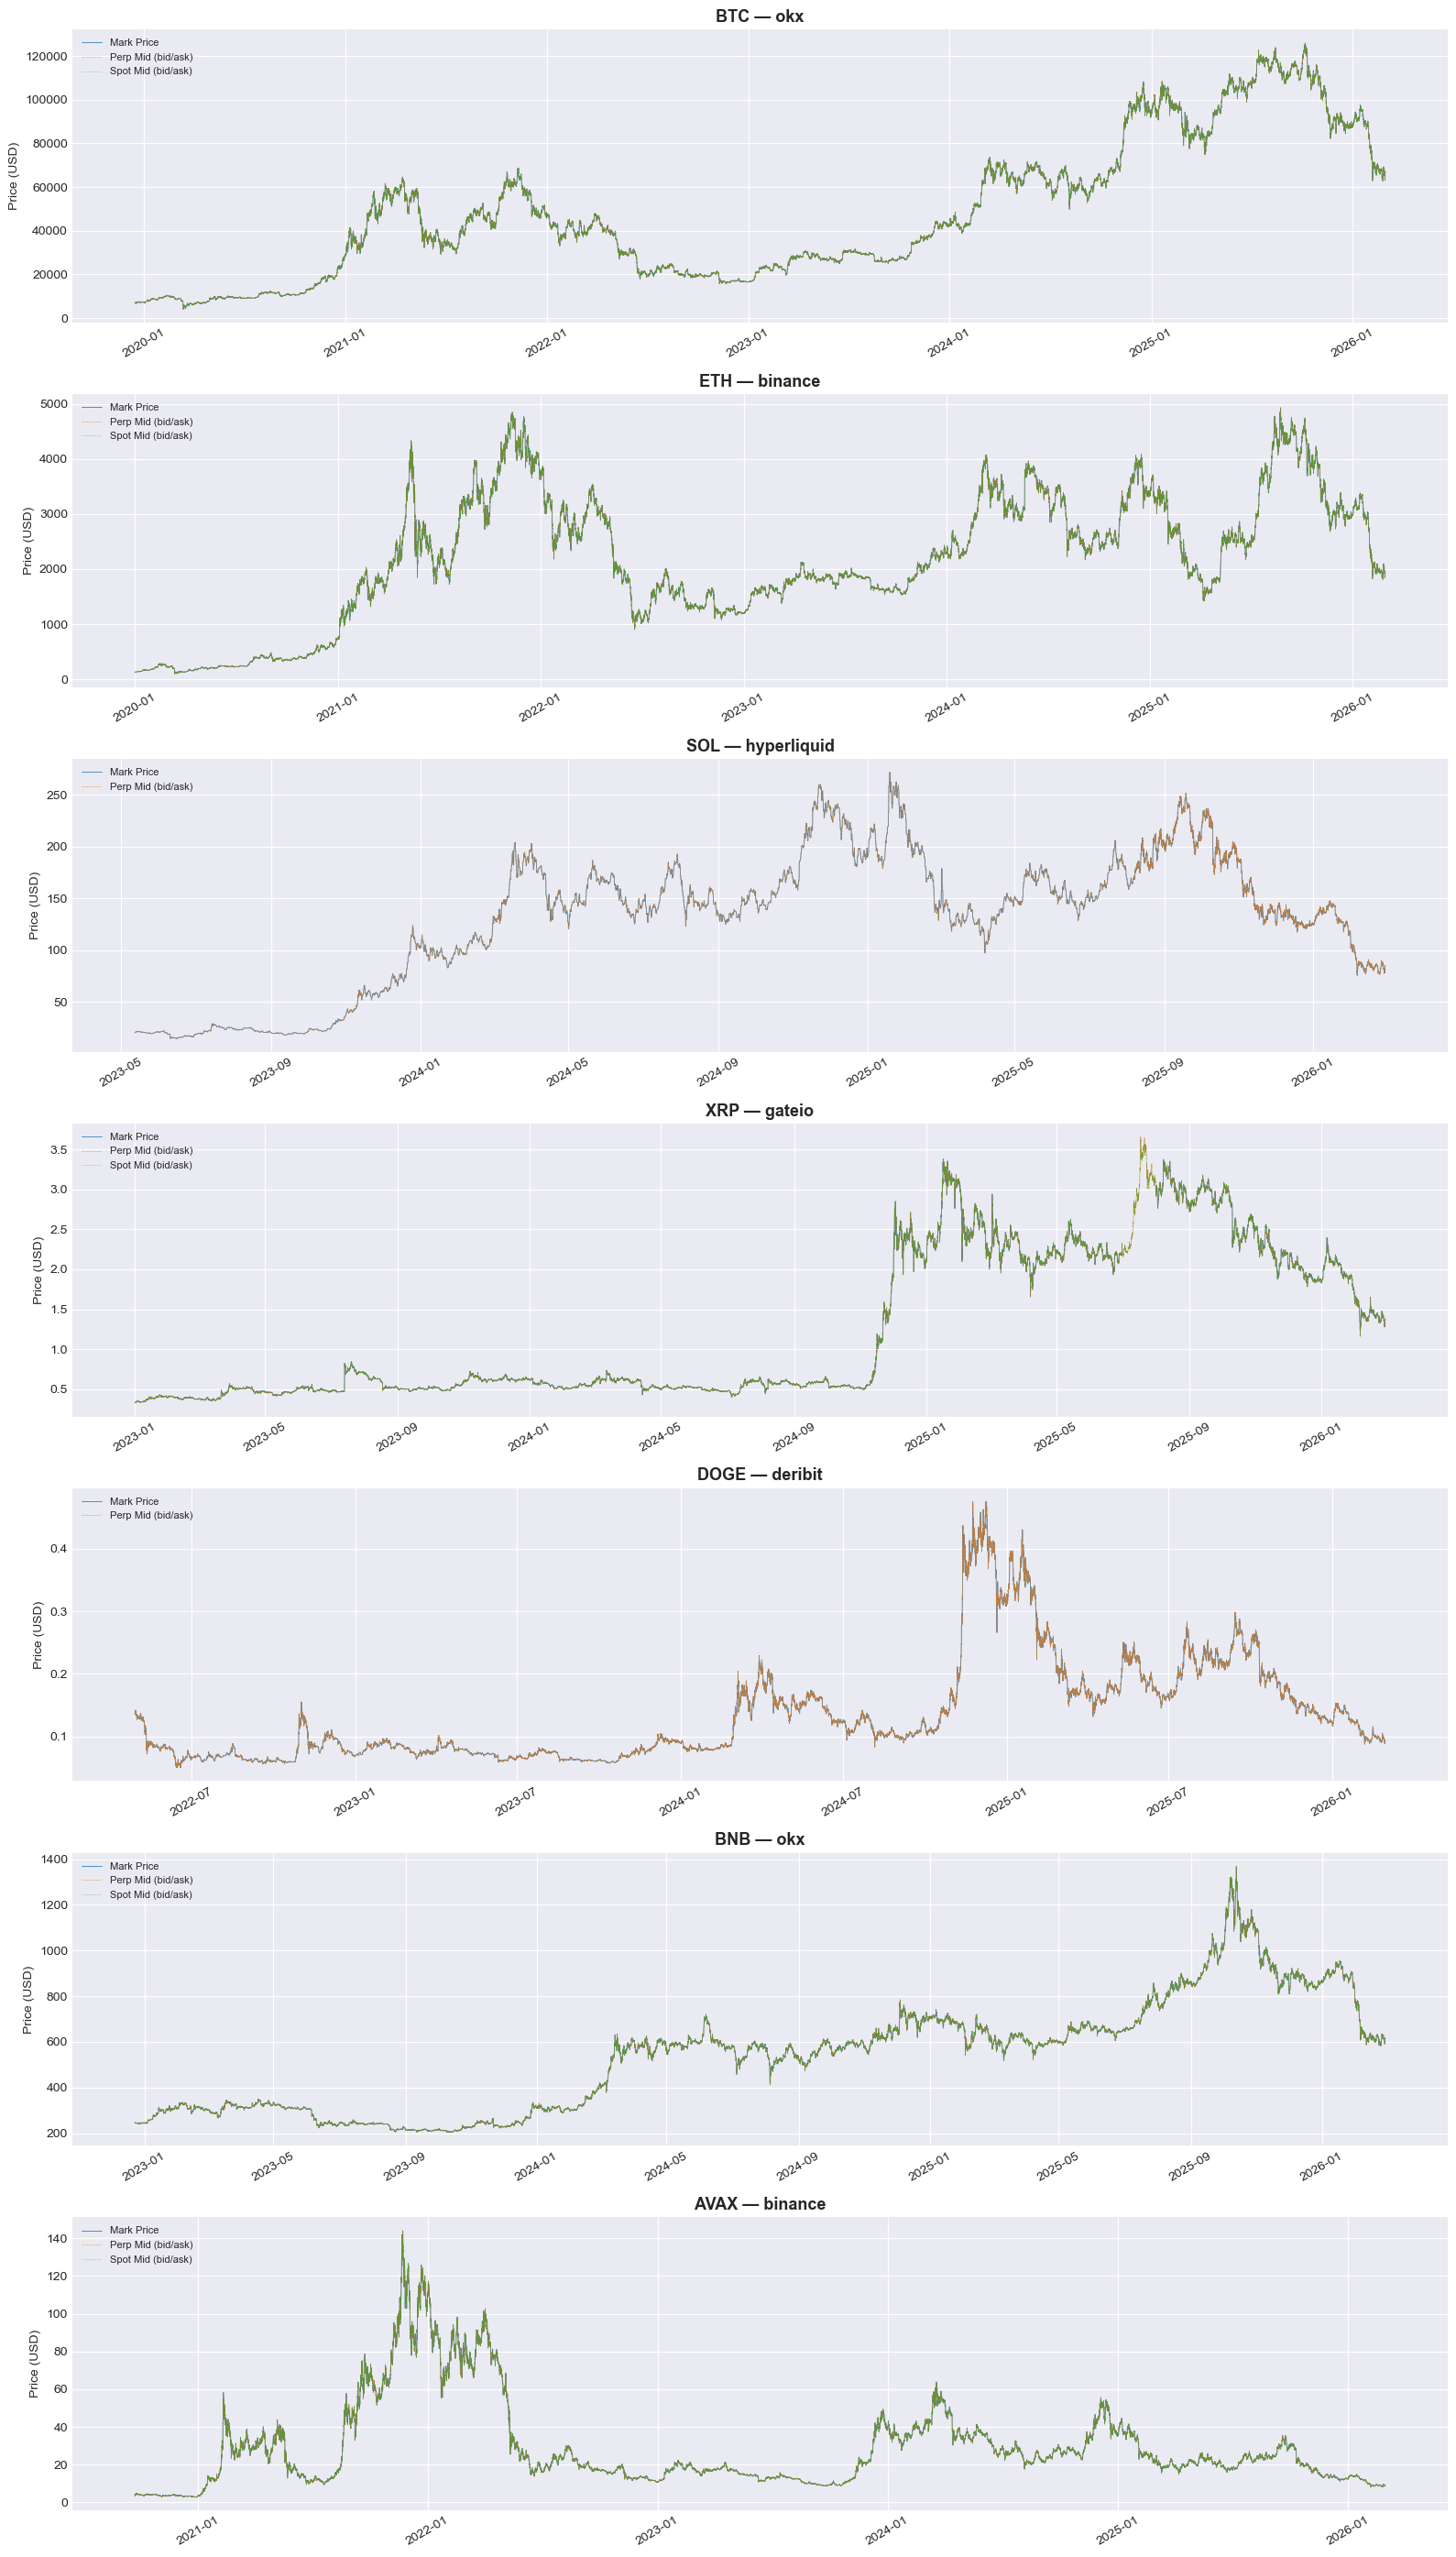

In [4]:
fig, axes = plt.subplots(len(dfs), 1, figsize=(16, 4 * len(dfs)), sharex=False)

for ax, (coin, df) in zip(axes, dfs.items()):
    ax.plot(df.index, df['mark_price'], label='Mark Price', linewidth=0.6, alpha=0.9)
    ax.plot(df.index, df['perp_mid'], label='Perp Mid (bid/ask)', linewidth=0.5, alpha=0.7, linestyle='--')
    if df['spot_mid'].notna().any():
        ax.plot(df.index, df['spot_mid'], label='Spot Mid (bid/ask)', linewidth=0.5, alpha=0.7, linestyle=':')
    ax.set_title(f'{coin} — {df["exchange"].iloc[0]}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Funding Rate Time Series

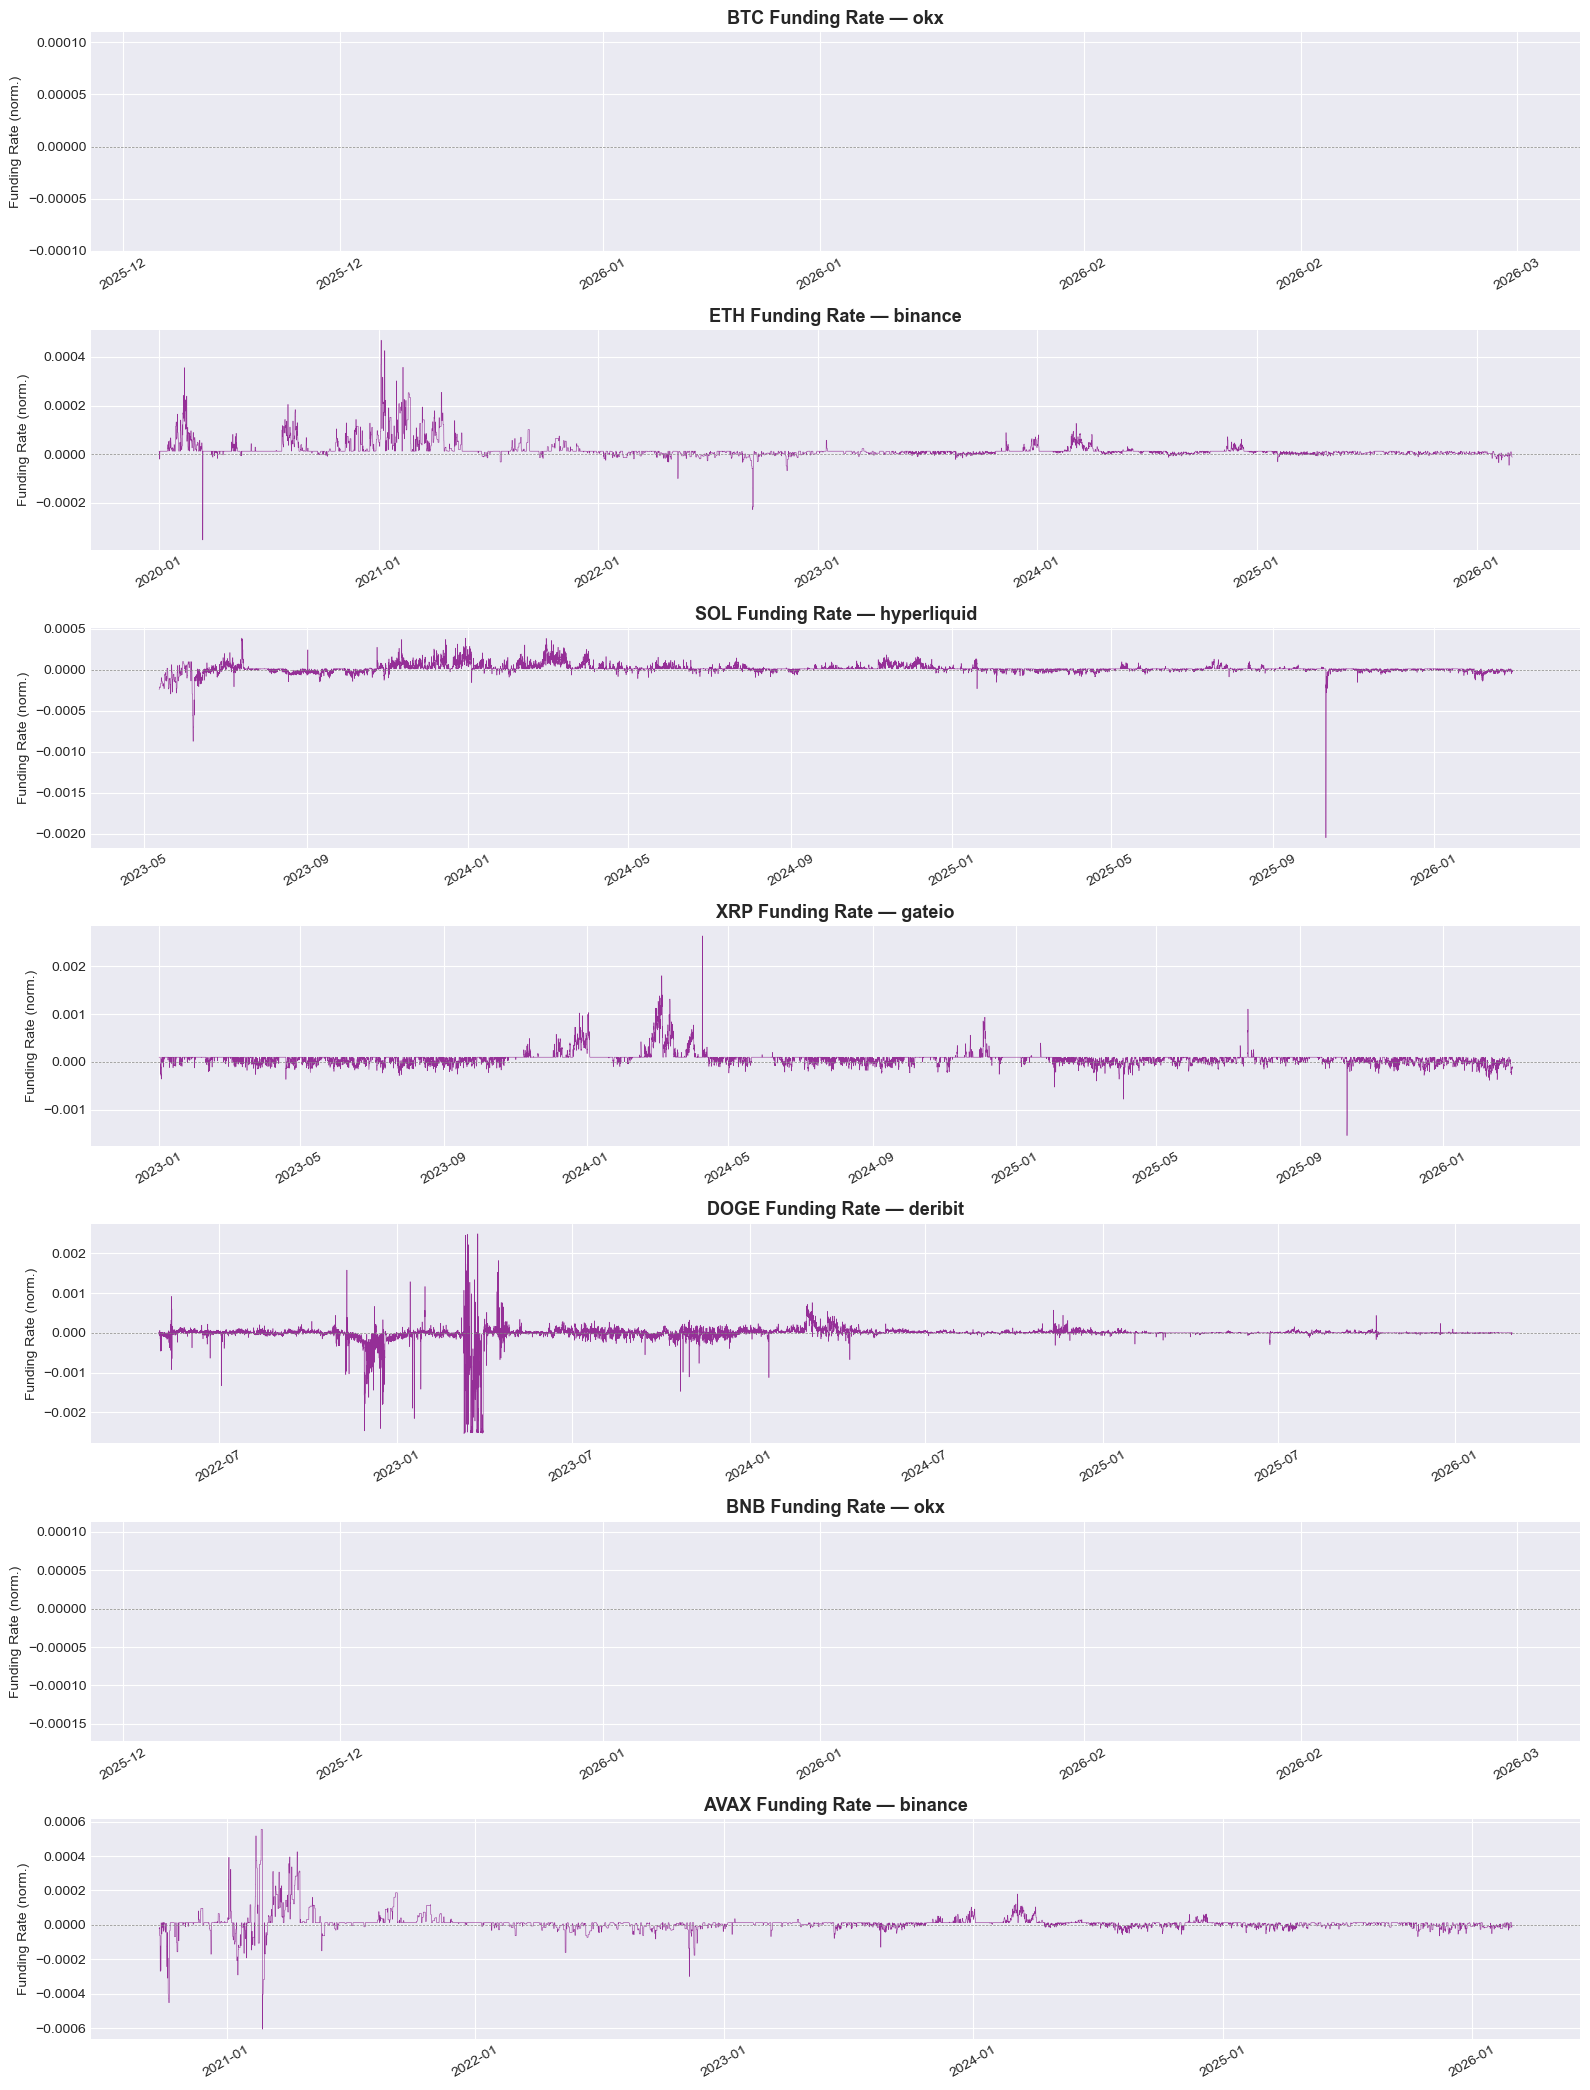

In [5]:
fig, axes = plt.subplots(len(dfs), 1, figsize=(16, 3 * len(dfs)), sharex=False)

for ax, (coin, df) in zip(axes, dfs.items()):
    ax.plot(df.index, df['funding_rate_normalized'], linewidth=0.4, color='purple', alpha=0.8)
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_title(f'{coin} Funding Rate — {df["exchange"].iloc[0]}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Funding Rate (norm.)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Perp vs Spot Basis (Perp Mid − Spot Mid)

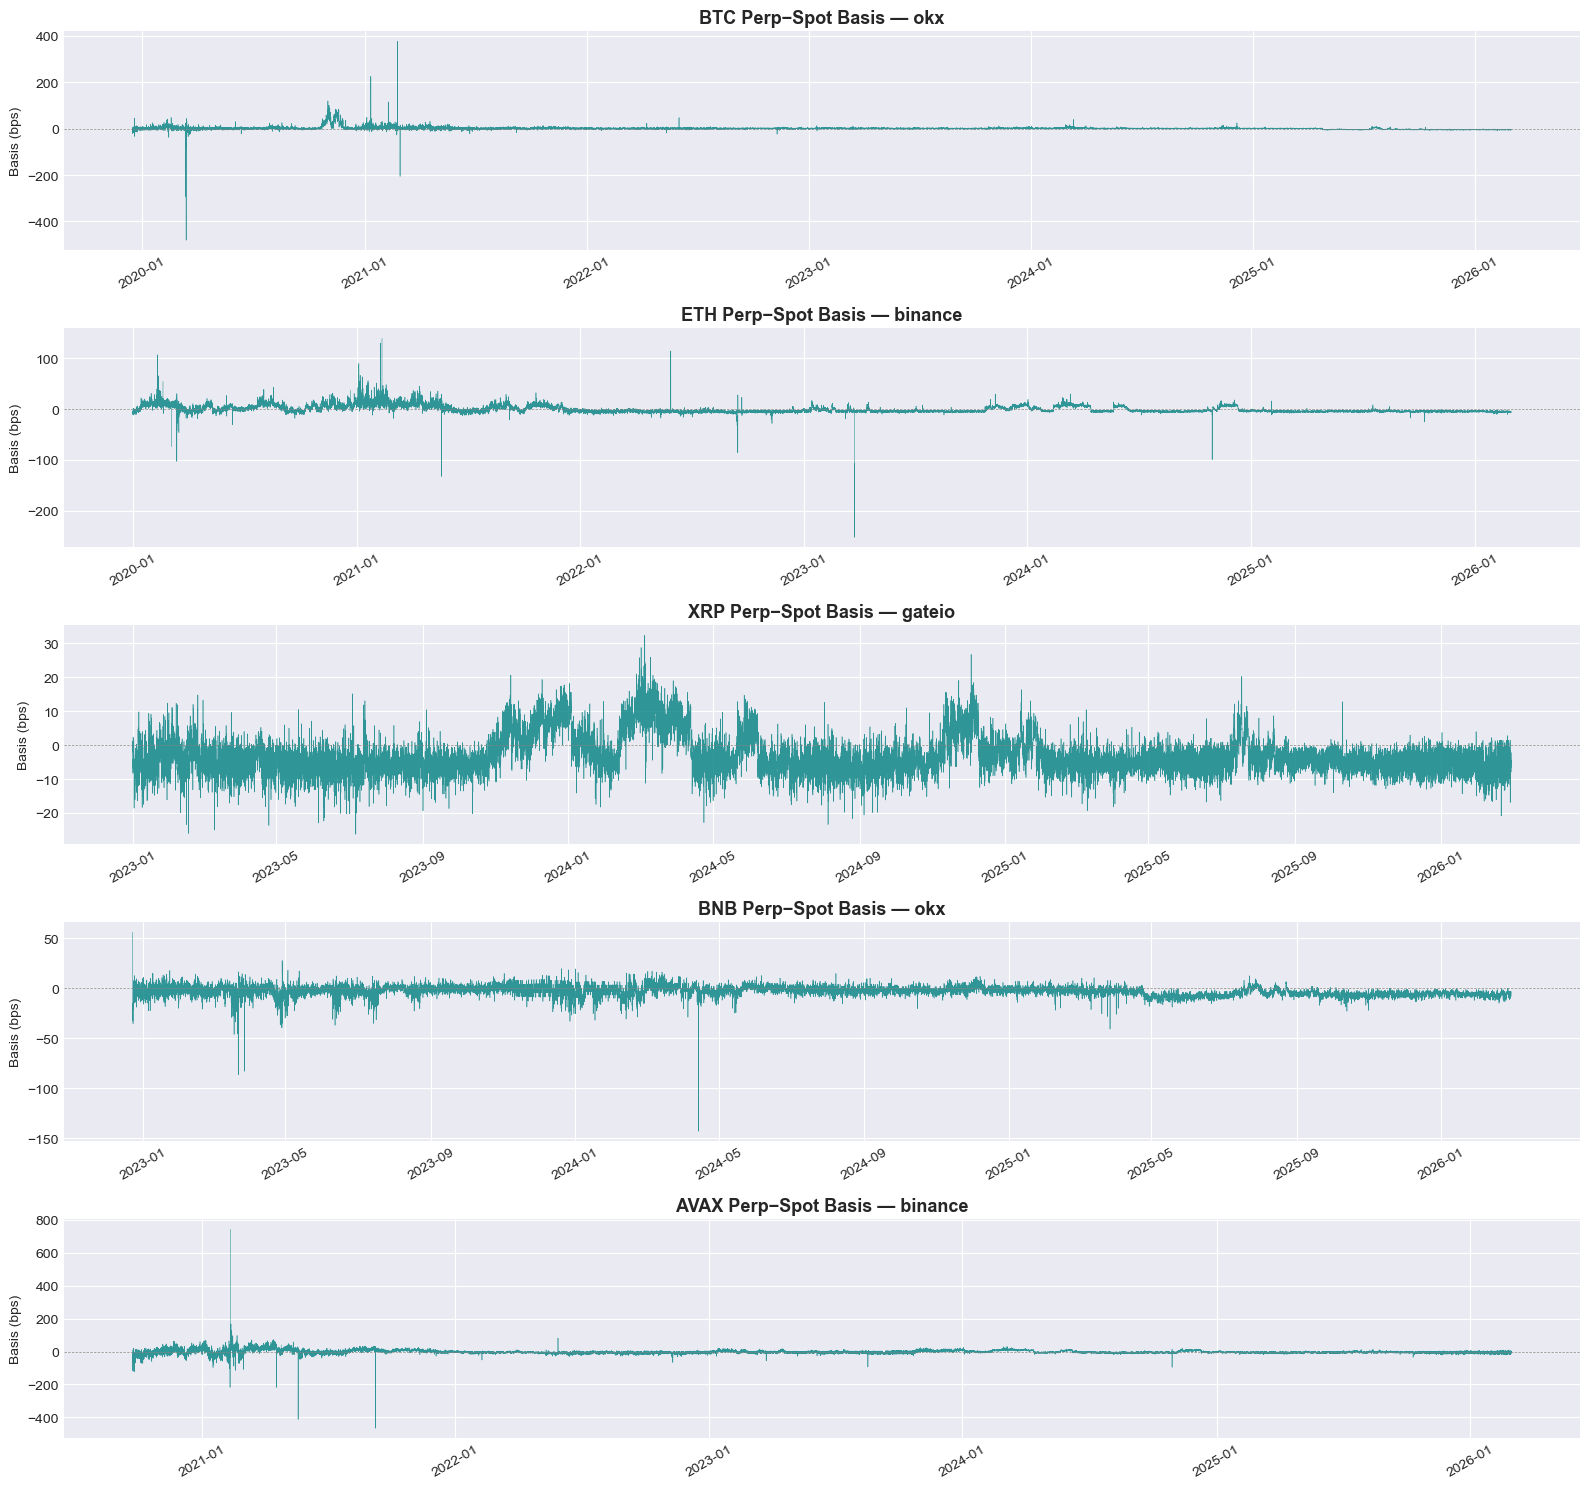


Note: Basis not shown for SOL, DOGE (no spot data from those exchanges).


In [6]:
# Only plot basis for coins that have spot data
coins_with_spot = {c: df for c, df in dfs.items() if df['spot_mid'].notna().any()}

fig, axes = plt.subplots(len(coins_with_spot), 1, figsize=(16, 3 * len(coins_with_spot)), sharex=False)
if len(coins_with_spot) == 1:
    axes = [axes]

for ax, (coin, df) in zip(axes, coins_with_spot.items()):
    basis_bps = (df['perp_mid'] - df['spot_mid']) / df['spot_mid'] * 10000
    ax.plot(df.index, basis_bps, linewidth=0.4, color='teal', alpha=0.8)
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_title(f'{coin} Perp−Spot Basis — {df["exchange"].iloc[0]}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Basis (bps)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f'\nNote: Basis not shown for {", ".join(set(dfs) - set(coins_with_spot))} (no spot data from those exchanges).')

Clear pattern — it's entirely exchange-level, nothing to do with the coin:

Exchange	Has Spot Data?
Binance	YES
OKX	YES
Gate.io	YES
Deribit	NO
Hyperliquid	NO
Deribit and Hyperliquid are missing spot bid/ask across all 7 coins. This makes sense — Deribit is a derivatives-only exchange (no spot market), and Hyperliquid is a perps-only DEX. They simply don't have spot order books to pull data from, so the data fetching wouldn't have been able to collect spot quotes from them.

SOL and DOGE aren't the issue — if you swapped to e.g. Binance or OKX for those coins you'd get spot data just fine.